# Load Dateset

In [10]:
import pandas as pd
import numpy as np

In [11]:
file_path = r"D:\Universitas Brawijaya_Roganda\BELAJAR_MANDIRI\DataScience\Project\StudentPerformanceFactors\dataset\Modeling1_StudentPerformanceFactors.csv"

df = pd.read_csv(file_path)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Hours_Studied                   6607 non-null   int64  
 1   Attendance                      6607 non-null   int64  
 2   Parental_Involvement            6607 non-null   float64
 3   Access_to_Resources             6607 non-null   float64
 4   Sleep_Hours                     6607 non-null   int64  
 5   Previous_Scores                 6607 non-null   int64  
 6   Motivation_Level                6607 non-null   float64
 7   Tutoring_Sessions               6607 non-null   int64  
 8   Family_Income                   6607 non-null   float64
 9   Teacher_Quality                 6607 non-null   float64
 10  Peer_Influence                  6607 non-null   float64
 11  Physical_Activity               6607 non-null   int64  
 12  Parental_Education_Level        6607 non-null

In [13]:
df.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Gender_Male,School_Type_Public,Internet_Access_Yes,Extracurricular_Activities_Yes,Learning_Disabilities_Yes,Exam_Score
0,23,84,0.0,2.0,7,73,0.0,0,0.0,1.0,2.0,3,0.0,0.0,1.0,1.0,1.0,0.0,0.0,67
1,19,64,0.0,1.0,8,59,0.0,2,1.0,1.0,0.0,4,1.0,1.0,0.0,1.0,1.0,0.0,0.0,61
2,24,98,1.0,1.0,7,91,1.0,2,1.0,1.0,1.0,4,2.0,0.0,1.0,1.0,1.0,1.0,0.0,74
3,29,89,0.0,1.0,8,98,1.0,1,1.0,1.0,0.0,4,0.0,1.0,1.0,1.0,1.0,1.0,0.0,71
4,19,92,1.0,1.0,6,65,1.0,3,1.0,2.0,1.0,4,1.0,0.0,0.0,1.0,1.0,1.0,0.0,70
5,19,88,1.0,1.0,8,89,1.0,3,1.0,1.0,2.0,3,2.0,0.0,1.0,1.0,1.0,1.0,0.0,71
6,29,84,1.0,0.0,7,68,0.0,1,0.0,1.0,1.0,2,0.0,1.0,1.0,0.0,1.0,1.0,0.0,67
7,25,78,0.0,2.0,6,50,1.0,1,2.0,2.0,0.0,2,0.0,2.0,1.0,1.0,1.0,1.0,0.0,66
8,17,94,1.0,2.0,6,80,2.0,0,1.0,0.0,1.0,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,69
9,23,98,1.0,1.0,8,71,1.0,0,2.0,2.0,2.0,5,0.0,1.0,1.0,1.0,1.0,1.0,0.0,72


# Modeling

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Exam_Score'])
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (5285, 19)
Test shape : (1322, 19)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
}

In [18]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False).reset_index(drop=True)
print(results_df)

               Model       MAE      RMSE        R2
0              Ridge  0.446922  1.800297  0.770707
1  Linear Regression  0.446907  1.800305  0.770705
2              Lasso  0.564653  1.830869  0.762854
3  Gradient Boosting  0.664840  1.884301  0.748810
4            XGBoost  0.855678  2.058483  0.700224
5      Random Forest  1.066305  2.148116  0.673549


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7484\2466364080.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="R2", y="Model", palette="coolwarm")


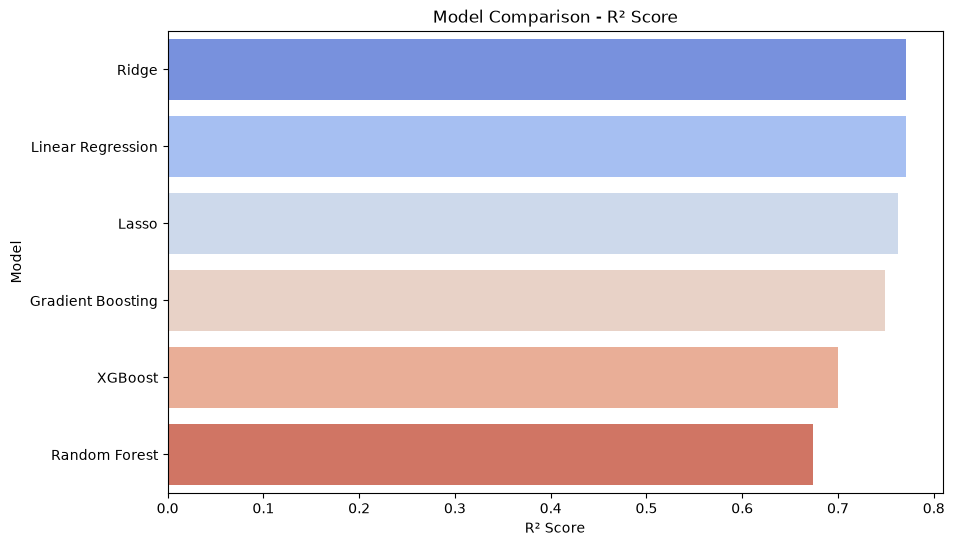

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="R2", y="Model", palette="coolwarm")
plt.title("Model Comparison - R² Score")
plt.xlabel("R² Score")
plt.show()

In [20]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"Best model: {best_model_name}")

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f"Feature Importance ({best_model_name})")
    plt.show()
else:
    print("Model ini gak punya feature_importances_ (biasanya linear model), cek .coef_ sebagai gantinya.")

Best model: Ridge
Model ini gak punya feature_importances_ (biasanya linear model), cek .coef_ sebagai gantinya.
